In [0]:
# Load Attendance Data
path = "/Volumes/rg_azure_databricks/week_4/file"
attendance_df = spark.read.format("csv").option("header","true").option("inferSchema","true").load(f"{path}/attendance.csv")

display(attendance_df)

employee_id,employee_name,department,attendance_date,clock_in,clock_out,status
101,John Smith,IT,2026-06-01,2026-06-23T09:00:00Z,2026-06-23T18:00:00Z,Present
102,Alice Johnson,HR,2026-06-01,2026-06-23T09:15:00Z,2026-06-23T17:45:00Z,Present
103,Michael Brown,Finance,2026-06-01,2026-06-23T08:50:00Z,2026-06-23T17:30:00Z,Present
104,Sarah Davis,Sales,2026-06-01,2026-06-23T09:05:00Z,2026-06-23T18:15:00Z,Present
105,David Wilson,IT,2026-06-01,2026-06-23T09:30:00Z,2026-06-23T18:00:00Z,Present
106,Emma Taylor,HR,2026-06-01,null,null,Absent
107,James Anderson,Finance,2026-06-01,2026-06-23T09:10:00Z,2026-06-23T17:40:00Z,Present
108,Olivia Thomas,Sales,2026-06-01,2026-06-23T08:55:00Z,2026-06-23T18:10:00Z,Present
109,William Martin,IT,2026-06-01,null,null,Absent
110,Sophia Lee,HR,2026-06-01,2026-06-23T09:00:00Z,2026-06-23T17:30:00Z,Present


In [0]:
# Load Task Data
task_df = spark.read.format("csv").option("header","true").option("inferSchema","true").load(f"{path}/tasks.csv")

display(task_df)

employee_id,tasks_completed,tasks_pending,feedback
101,22,3,Excellent
102,18,2,Good
103,20,4,Good
104,30,5,Excellent
105,16,6,Average
106,0,0,Absent
107,19,4,Good
108,32,3,Excellent
109,0,0,Absent
110,15,3,Average


In [0]:
# Data Cleaning
from pyspark.sql.functions import *

attendance_clean = attendance_df.dropna()
task_clean = task_df.dropna()
attendance_clean = attendance_clean.dropDuplicates()
task_clean = task_clean.dropDuplicates()

In [0]:
# Calculate Work Hours
attendance_hours = attendance_clean.withColumn(
    "work_hours",
    (
        unix_timestamp("clock_out") -
        unix_timestamp("clock_in")
    ) / 3600
)

display(attendance_hours)

employee_id,employee_name,department,attendance_date,clock_in,clock_out,status,work_hours
108,Olivia Thomas,Sales,2026-06-01,2026-06-23T08:55:00Z,2026-06-23T18:10:00Z,Present,9.25
111,Daniel White,Finance,2026-06-01,2026-06-23T09:20:00Z,2026-06-23T18:00:00Z,Present,8.666666666666666
102,Alice Johnson,HR,2026-06-01,2026-06-23T09:15:00Z,2026-06-23T17:45:00Z,Present,8.5
114,Mia Lewis,HR,2026-06-01,2026-06-23T09:05:00Z,2026-06-23T18:00:00Z,Present,8.916666666666666
101,John Smith,IT,2026-06-01,2026-06-23T09:00:00Z,2026-06-23T18:00:00Z,Present,9.0
105,David Wilson,IT,2026-06-01,2026-06-23T09:30:00Z,2026-06-23T18:00:00Z,Present,8.5
110,Sophia Lee,HR,2026-06-01,2026-06-23T09:00:00Z,2026-06-23T17:30:00Z,Present,8.5
107,James Anderson,Finance,2026-06-01,2026-06-23T09:10:00Z,2026-06-23T17:40:00Z,Present,8.5
104,Sarah Davis,Sales,2026-06-01,2026-06-23T09:05:00Z,2026-06-23T18:15:00Z,Present,9.166666666666666
113,Matthew Clark,IT,2026-06-01,2026-06-23T08:45:00Z,2026-06-23T17:45:00Z,Present,9.0


In [0]:
# Join Attendance and Task Data
employee_df = attendance_hours.join(
    task_clean,
    "employee_id",
    "inner"
)

display(employee_df)

employee_id,employee_name,department,attendance_date,clock_in,clock_out,status,work_hours,tasks_completed,tasks_pending,feedback
108,Olivia Thomas,Sales,2026-06-01,2026-06-23T08:55:00Z,2026-06-23T18:10:00Z,Present,9.25,32,3,Excellent
111,Daniel White,Finance,2026-06-01,2026-06-23T09:20:00Z,2026-06-23T18:00:00Z,Present,8.666666666666666,21,2,Good
102,Alice Johnson,HR,2026-06-01,2026-06-23T09:15:00Z,2026-06-23T17:45:00Z,Present,8.5,18,2,Good
114,Mia Lewis,HR,2026-06-01,2026-06-23T09:05:00Z,2026-06-23T18:00:00Z,Present,8.916666666666666,17,3,Good
101,John Smith,IT,2026-06-01,2026-06-23T09:00:00Z,2026-06-23T18:00:00Z,Present,9.0,22,3,Excellent
105,David Wilson,IT,2026-06-01,2026-06-23T09:30:00Z,2026-06-23T18:00:00Z,Present,8.5,16,6,Average
110,Sophia Lee,HR,2026-06-01,2026-06-23T09:00:00Z,2026-06-23T17:30:00Z,Present,8.5,15,3,Average
107,James Anderson,Finance,2026-06-01,2026-06-23T09:10:00Z,2026-06-23T17:40:00Z,Present,8.5,19,4,Good
104,Sarah Davis,Sales,2026-06-01,2026-06-23T09:05:00Z,2026-06-23T18:15:00Z,Present,9.166666666666666,30,5,Excellent
113,Matthew Clark,IT,2026-06-01,2026-06-23T08:45:00Z,2026-06-23T17:45:00Z,Present,9.0,24,2,Excellent


In [0]:
# Create Productivity Score
employee_df = employee_df.withColumn(
    "productivity_score",
    round(
        col("tasks_completed") / col("work_hours"),
        2
    )
)

display(employee_df)

employee_id,employee_name,department,attendance_date,clock_in,clock_out,status,work_hours,tasks_completed,tasks_pending,feedback,productivity_score
108,Olivia Thomas,Sales,2026-06-01,2026-06-23T08:55:00Z,2026-06-23T18:10:00Z,Present,9.25,32,3,Excellent,3.46
111,Daniel White,Finance,2026-06-01,2026-06-23T09:20:00Z,2026-06-23T18:00:00Z,Present,8.666666666666666,21,2,Good,2.42
102,Alice Johnson,HR,2026-06-01,2026-06-23T09:15:00Z,2026-06-23T17:45:00Z,Present,8.5,18,2,Good,2.12
114,Mia Lewis,HR,2026-06-01,2026-06-23T09:05:00Z,2026-06-23T18:00:00Z,Present,8.916666666666666,17,3,Good,1.91
101,John Smith,IT,2026-06-01,2026-06-23T09:00:00Z,2026-06-23T18:00:00Z,Present,9.0,22,3,Excellent,2.44
105,David Wilson,IT,2026-06-01,2026-06-23T09:30:00Z,2026-06-23T18:00:00Z,Present,8.5,16,6,Average,1.88
110,Sophia Lee,HR,2026-06-01,2026-06-23T09:00:00Z,2026-06-23T17:30:00Z,Present,8.5,15,3,Average,1.76
107,James Anderson,Finance,2026-06-01,2026-06-23T09:10:00Z,2026-06-23T17:40:00Z,Present,8.5,19,4,Good,2.24
104,Sarah Davis,Sales,2026-06-01,2026-06-23T09:05:00Z,2026-06-23T18:15:00Z,Present,9.166666666666666,30,5,Excellent,3.27
113,Matthew Clark,IT,2026-06-01,2026-06-23T08:45:00Z,2026-06-23T17:45:00Z,Present,9.0,24,2,Excellent,2.67


In [0]:
# Department Level Metrics
dept_metrics = employee_df.groupBy("department").agg(
    round(avg("work_hours"),2).alias("avg_work_hours"),
    round(avg("productivity_score"),2).alias("avg_productivity"),
    sum("tasks_completed").alias("total_tasks")
)

display(dept_metrics)

department,avg_work_hours,avg_productivity,total_tasks
Sales,9.25,3.24,90
HR,8.64,1.93,50
Finance,8.61,2.32,60
IT,8.83,2.33,62


In [0]:
# Frequent Absentees
absentees = attendance_clean.groupBy(
    "employee_id",
    "employee_name",
    "department"
).count()

display(absentees.orderBy("count"))

employee_id,employee_name,department,count
107,James Anderson,Finance,1
102,Alice Johnson,HR,1
114,Mia Lewis,HR,1
104,Sarah Davis,Sales,1
105,David Wilson,IT,1
108,Olivia Thomas,Sales,1
101,John Smith,IT,1
113,Matthew Clark,IT,1
111,Daniel White,Finance,1
112,Isabella Harris,Sales,1


In [0]:
# Top Performers
top_performers = employee_df.orderBy(
    col("productivity_score").desc()
)

display(top_performers)

employee_id,employee_name,department,attendance_date,clock_in,clock_out,status,work_hours,tasks_completed,tasks_pending,feedback,productivity_score
108,Olivia Thomas,Sales,2026-06-01,2026-06-23T08:55:00Z,2026-06-23T18:10:00Z,Present,9.25,32,3,Excellent,3.46
104,Sarah Davis,Sales,2026-06-01,2026-06-23T09:05:00Z,2026-06-23T18:15:00Z,Present,9.166666666666666,30,5,Excellent,3.27
112,Isabella Harris,Sales,2026-06-01,2026-06-23T09:00:00Z,2026-06-23T18:20:00Z,Present,9.333333333333334,28,4,Excellent,3.0
113,Matthew Clark,IT,2026-06-01,2026-06-23T08:45:00Z,2026-06-23T17:45:00Z,Present,9.0,24,2,Excellent,2.67
101,John Smith,IT,2026-06-01,2026-06-23T09:00:00Z,2026-06-23T18:00:00Z,Present,9.0,22,3,Excellent,2.44
111,Daniel White,Finance,2026-06-01,2026-06-23T09:20:00Z,2026-06-23T18:00:00Z,Present,8.666666666666666,21,2,Good,2.42
103,Michael Brown,Finance,2026-06-01,2026-06-23T08:50:00Z,2026-06-23T17:30:00Z,Present,8.666666666666666,20,4,Good,2.31
107,James Anderson,Finance,2026-06-01,2026-06-23T09:10:00Z,2026-06-23T17:40:00Z,Present,8.5,19,4,Good,2.24
102,Alice Johnson,HR,2026-06-01,2026-06-23T09:15:00Z,2026-06-23T17:45:00Z,Present,8.5,18,2,Good,2.12
114,Mia Lewis,HR,2026-06-01,2026-06-23T09:05:00Z,2026-06-23T18:00:00Z,Present,8.916666666666666,17,3,Good,1.91


In [0]:
# Save as Delta Table
dept_metrics.write.format("delta").mode("overwrite").save("/FileStore/employee_kpi_delta")

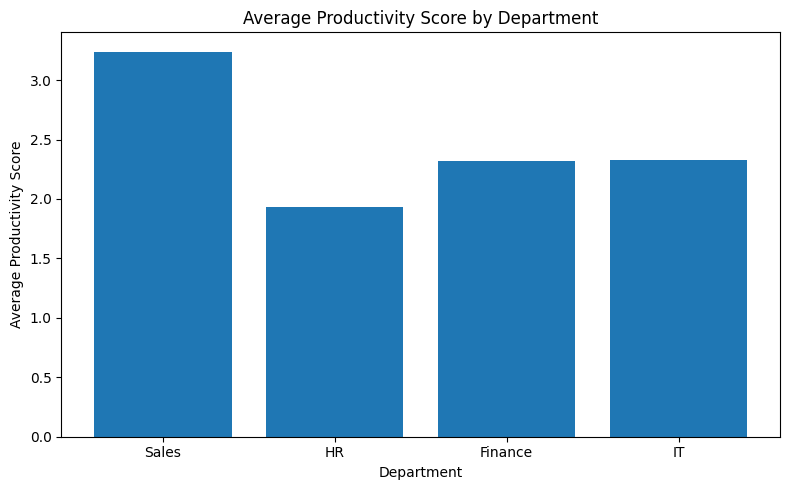

In [0]:
# KPI Visualization
import matplotlib.pyplot as plt

kpi_df = dept_metrics.toPandas()

plt.figure(figsize=(8,5))

plt.bar(
    kpi_df["department"],
    kpi_df["avg_productivity"]
)

plt.title("Average Productivity Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Productivity Score")

plt.tight_layout()
plt.show()

In [0]:
# KPI Summary 
total_employees = employee_df.select("employee_id").distinct().count()

avg_hours = employee_df.selectExpr(
    "round(avg(work_hours),2) as avg_hours"
).collect()[0][0]

avg_productivity = employee_df.selectExpr(
    "round(avg(productivity_score),2) as avg_prod"
).collect()[0][0]

total_tasks = employee_df.agg(
    sum("tasks_completed")
).collect()[0][0]

print("========== EMPLOYEE KPI DASHBOARD ==========")
print(f"Total Employees      : {total_employees}")
print(f"Average Work Hours   : {avg_hours}")
print(f"Average Productivity : {avg_productivity}")
print(f"Total Tasks Done     : {total_tasks}")

========== EMPLOYEE KPI DASHBOARD ==========
Total Employees      : 12
Average Work Hours   : 8.83
Average Productivity : 2.46
Total Tasks Done     : 262
